# 02b — Digitization Style Comparison (N participants)

General-purpose version of `02a`. Works for 2 or 3 participants.

**File naming conventions:**
- Assignment CSV: `{settlement}_1km_road_intersect_{lastname}_assignments.csv`
- Digitization file: any path relative to `data/processed/sample_digitization/` —
  supply it explicitly in `PARTICIPANTS` below. Supported formats: `.geojson`, `.gpkg`,
  `.shp` (companions auto-found), or a path into a subdirectory.

**Overlap cells** are determined by intersecting `is_overlap=True` OIDs across all
participants' assignment files. Only cells shared by every participant are analysed.

**Metrics per cell:** total road length (m), road density (m/km²), segment count,
node count, mean segment length (m).

**Pairwise analysis:** all unique participant pairs get scatter plots, IoU maps, and
paired statistical tests. With 2 participants there is 1 pair; with 3 there are 3.

**Inside vs outside settlement:** all per-cell metrics and IoU are broken out by
whether the cell centroid falls inside the UNHCR settlement boundary.

**Random cell explorer:** re-run the last cell to draw a fresh random overlap cell
with all participants overlaid on a single axes.

In [2]:
# ── Parameters — edit this cell only ─────────────────────────────────────────

SETTLEMENT = "palabek"   # used to build grid/boundary filenames and assignment filenames

# One entry per participant.
#   lastname : matches the assignment CSV suffix and is used as the display label
#   dig_file : path relative to data/processed/sample_digitization/
#              Can be a .geojson, .gpkg, or .shp (companion files auto-found).
#              For files in subdirectories supply the full relative path.
PARTICIPANTS = [
    {"lastname": "hank",  "dig_file": "Lawit-S2-digitize.geojson"},
    {"lastname": "tanna", "dig_file": "Sample_Digitization_Palabek_Tanna.geojson"},
    # Third participant example — uncomment and fill in:
    # {"lastname": "casey",
    #  "dig_file": "sample_digitization_schenker_2-20260409T223642Z-3-001/"
    #              "sample_digitization_schenker_2/sample_digitization_schenket_2.shp"},
]

PROJECTED_CRS   = "EPSG:32636"  # UTM Zone 36N
CELL_SIZE_M     = 1000          # grid cell side length in metres
SNAP_BUFFER_M   = 5             # buffer radius (m) for geometric IoU calculation
N_EXAMPLE_CELLS = 6             # cells to show in individual-cell map panels

In [3]:
import warnings
from itertools import combinations
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import yaml
from scipy import stats
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.1f}".format)

In [4]:
def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("configs/paths.yaml not found")

project_root = find_project_root()
with open(project_root / "configs" / "paths.yaml") as f:
    _paths = yaml.safe_load(f)

processed_dir = project_root / _paths["data"]["processed"]
assign_dir    = processed_dir / "assignments"
dig_dir       = processed_dir / "sample_digitization"

# Derived colour palette — consistent whether 2 or 3 participants
_PALETTE = ["#2166ac", "#d6604d", "#1a9641", "#762a83"]
LABELS   = [p["lastname"].capitalize() for p in PARTICIPANTS]
COLORS   = {label: _PALETTE[i] for i, label in enumerate(LABELS)}

print(f"Settlement   : {SETTLEMENT}")
print(f"Participants : {LABELS}")
print(f"Processed dir: {processed_dir}")

Settlement   : palabek
Participants : ['Hank', 'Tanna']
Processed dir: C:\Users\Zachary\phd_classes\uganda\data\processed


## 1  Load data

In [5]:
# ── Grid cells ────────────────────────────────────────────────────────────────
grid = gpd.read_file(processed_dir / f"{SETTLEMENT}_1km_grids.geojson").to_crs(PROJECTED_CRS)
print(f"Grid cells: {len(grid)}  CRS: {grid.crs.to_epsg()}")

# ── Settlement boundary ───────────────────────────────────────────────────────
boundary_path = processed_dir / f"UNHCR_poc_boundaries-Uganda_{SETTLEMENT}_utm36N.geojson"
settlement    = gpd.read_file(boundary_path).to_crs(PROJECTED_CRS)
settlement_union = settlement.geometry.unary_union
print(f"Settlement boundary loaded: {boundary_path.name}")

# ── Assignment CSVs + digitization files ─────────────────────────────────────
# geopandas.read_file() natively handles .geojson, .gpkg, and .shp (with companions).
# For files in subdirectories, dig_file is the relative path from dig_dir.
assign_dfs = {}
lines_gdfs = {}

for p in PARTICIPANTS:
    label    = p["lastname"].capitalize()
    csv_path = assign_dir / f"{SETTLEMENT}_1km_road_intersect_{p['lastname']}_assignments.csv"
    assign_dfs[label] = pd.read_csv(csv_path)
    print(f"  {label} assignment : {len(assign_dfs[label])} rows  ({csv_path.name})")

    dig_path = dig_dir / p["dig_file"]
    raw = gpd.read_file(dig_path).to_crs(PROJECTED_CRS)
    lines_gdfs[label] = raw.explode(index_parts=False).reset_index(drop=True)
    print(f"  {label} digitization: {len(lines_gdfs[label])} lines  ({dig_path.name})")

Grid cells: 1281  CRS: 32636
Settlement boundary loaded: UNHCR_poc_boundaries-Uganda_palabek_utm36N.geojson
  Hank assignment : 384 rows  (palabek_1km_road_intersect_hank_assignments.csv)
  Hank digitization: 197 lines  (Lawit-S2-digitize.geojson)
  Tanna assignment : 384 rows  (palabek_1km_road_intersect_tanna_assignments.csv)
  Tanna digitization: 1032 lines  (Sample_Digitization_Palabek_Tanna.geojson)


In [6]:
# ── Identify overlap cells ────────────────────────────────────────────────────
# A cell qualifies if is_overlap=True in EVERY participant's assignment file.
overlap_sets = {
    label: set(df.loc[df["is_overlap"], "OID"])
    for label, df in assign_dfs.items()
}
overlap_oids = sorted(set.intersection(*overlap_sets.values()))

for label, s in overlap_sets.items():
    print(f"  {label}: {len(s)} cells with is_overlap=True")
print(f"\nCells shared by ALL participants: {len(overlap_oids)}")
print(f"OIDs: {overlap_oids}")

overlap_grid = grid[grid["OID"].isin(overlap_oids)].copy().reset_index(drop=True)

# Tag each overlap cell: inside or outside settlement boundary (by centroid)
overlap_grid["inside_settlement"] = overlap_grid.geometry.centroid.within(settlement_union)
n_inside  = overlap_grid["inside_settlement"].sum()
n_outside = (~overlap_grid["inside_settlement"]).sum()
print(f"\nOverlap cells inside  settlement: {n_inside}")
print(f"Overlap cells outside settlement: {n_outside}")

  Hank: 44 cells with is_overlap=True
  Tanna: 44 cells with is_overlap=True

Cells shared by ALL participants: 22
OIDs: [621, 622, 657, 658, 659, 693, 694, 695, 729, 730, 731, 766, 767, 768, 802, 803, 804, 838, 839, 840, 874, 875]

Overlap cells inside  settlement: 5
Overlap cells outside settlement: 17


## 2  Per-cell metrics

In [7]:
CELL_AREA_KM2 = (CELL_SIZE_M / 1000) ** 2

def _count_nodes(geom) -> int:
    if geom is None or geom.is_empty:
        return 0
    t = geom.geom_type
    if t in ("LineString", "LinearRing"):
        return len(geom.coords)
    if t == "Point":
        return 1
    if t in ("MultiLineString", "MultiPoint", "MultiPolygon", "GeometryCollection"):
        return sum(_count_nodes(part) for part in geom.geoms)
    if t == "Polygon":
        return len(geom.exterior.coords) + sum(len(r.coords) for r in geom.interiors)
    return 0

def _extract_lines(geom):
    if geom is None or geom.is_empty:
        return []
    t = geom.geom_type
    if t in ("LineString", "LinearRing"):
        return [geom]
    if t == "MultiLineString":
        return list(geom.geoms)
    if t in ("GeometryCollection", "MultiPolygon", "MultiPoint"):
        result = []
        for part in geom.geoms:
            result.extend(_extract_lines(part))
        return result
    return []

def metrics_for_lines_in_cell(lines_gdf, cell_geom) -> dict:
    _empty = dict(n_segments=0, n_nodes=0, total_length_m=0.0,
                  density_m_per_km2=0.0, mean_seg_length_m=float("nan"))
    clipped = lines_gdf[lines_gdf.intersects(cell_geom)].copy()
    if clipped.empty:
        return _empty
    clipped["geometry"] = clipped.geometry.intersection(cell_geom)
    clipped = clipped[~clipped.geometry.is_empty].copy()
    if clipped.empty:
        return _empty
    all_lines = []
    for geom in clipped.geometry:
        all_lines.extend(_extract_lines(geom))
    if not all_lines:
        return _empty
    lengths = np.array([g.length for g in all_lines])
    total   = lengths.sum()
    return dict(
        n_segments        = len(all_lines),
        n_nodes           = int(sum(_count_nodes(g) for g in all_lines)),
        total_length_m    = total,
        density_m_per_km2 = total / CELL_AREA_KM2,
        mean_seg_length_m = float(lengths.mean()),
    )


rows = []
for _, cell_row in overlap_grid.iterrows():
    oid    = cell_row["OID"]
    cell   = cell_row.geometry
    inside = cell_row["inside_settlement"]
    for label, lines_gdf in lines_gdfs.items():
        rows.append({"OID": oid, "participant": label, "inside_settlement": inside,
                     **metrics_for_lines_in_cell(lines_gdf, cell)})

cell_metrics = pd.DataFrame(rows)
print(f"Metrics computed: {len(overlap_oids)} cells x {len(LABELS)} participants")
cell_metrics.head(len(LABELS) * 2)

Metrics computed: 22 cells x 2 participants


,OID,participant,inside_settlement,n_segments,n_nodes,total_length_m,density_m_per_km2,mean_seg_length_m
0,621,Hank,False,2,28,1176.8,1176.8,588.4
1,621,Tanna,False,4,41,1183.8,1183.8,295.9
2,622,Hank,True,3,24,1595.9,1595.9,532.0
3,622,Tanna,True,8,55,1274.7,1274.7,159.3


## 3  Aggregate statistics — all overlap cells

In [8]:
AGG_COLS = ["total_length_m", "density_m_per_km2", "n_segments", "n_nodes", "mean_seg_length_m"]

agg = cell_metrics.groupby("participant")[AGG_COLS].agg(["mean", "median", "std", "min", "max"])
print("=== Aggregate statistics — all overlap cells ===")
display(agg)

=== Aggregate statistics — all overlap cells ===


total_length_m                           density_m_per_km2         \
                      mean median    std  min    max              mean median   
participant                                                                     
Hank                1151.7 1133.2  932.3  0.0 3356.3            1151.7 1133.2   
Tanna               1846.5 1772.9 1170.6 21.1 4179.1            1846.5 1772.9   

                               n_segments                    n_nodes         \
               std  min    max       mean median std min max    mean median   
participant                                                                   
Hank         932.3  0.0 3356.3        2.1    2.0 1.7   0   6    17.6   20.5   
Tanna       1170.6 21.1 4179.1        5.4    4.5 3.2   1  14    66.0   61.5   

                          mean_seg_length_m                            
             std min  max              mean median   std   min    max  
participant                                                            
Hank        13.5   0   39             598.4  554.7 264.7 184.4 1156.9  
Tanna       42.3   2  170             342.4  317.0 181.4  21.1  865.1

In [9]:
# ── Paired statistical tests for every participant pair ───────────────────────
vals_by_p = {
    label: cell_metrics[cell_metrics["participant"] == label].set_index("OID")
    for label in LABELS
}
pairs = list(combinations(LABELS, 2))

stat_rows = []
for (lA, lB) in pairs:
    for col in AGG_COLS:
        a = vals_by_p[lA].loc[overlap_oids, col].values
        b = vals_by_p[lB].loc[overlap_oids, col].values
        mask = ~(np.isnan(a) | np.isnan(b))
        a, b = a[mask], b[mask]
        if len(a) < 3:
            continue
        _, t_p = stats.ttest_rel(a, b)
        w_p    = stats.wilcoxon(a, b).pvalue if not np.all(a == b) else np.nan
        stat_rows.append(dict(
            pair=f"{lA} vs {lB}", metric=col,
            mean_A=a.mean(), mean_B=b.mean(), mean_diff=(a - b).mean(),
            ttest_p=t_p, wilcoxon_p=w_p, n_pairs=len(a),
        ))

stat_df = pd.DataFrame(stat_rows)
print("=== Paired statistical tests ===")
display(stat_df.round(4))

=== Paired statistical tests ===


,pair,metric,mean_A,mean_B,mean_diff,ttest_p,wilcoxon_p,n_pairs
0,Hank vs Tanna,total_length_m,1151.7,1846.5,-694.9,0.0,0.0,22
1,Hank vs Tanna,density_m_per_km2,1151.7,1846.5,-694.9,0.0,0.0,22
2,Hank vs Tanna,n_segments,2.1,5.4,-3.3,0.0,0.0,22
3,Hank vs Tanna,n_nodes,17.6,66.0,-48.3,0.0,0.0,22
4,Hank vs Tanna,mean_seg_length_m,598.4,340.1,258.3,0.0,0.0,17


## 4  Inside vs outside settlement — metric comparison

Splits overlap cells by whether their centroid falls inside the UNHCR settlement boundary,
then compares per-participant means for each sub-group.

In [10]:
location_label = {True: "Inside", False: "Outside"}
cell_metrics["location"] = cell_metrics["inside_settlement"].map(location_label)

agg_location = (
    cell_metrics
    .groupby(["location", "participant"])[AGG_COLS]
    .mean()
    .round(1)
)
print("=== Mean per-cell metrics by location and participant ===")
display(agg_location)

=== Mean per-cell metrics by location and participant ===


total_length_m  density_m_per_km2  n_segments  n_nodes  \
location participant                                                           
Inside   Hank                 1597.7             1597.7         3.0     20.2   
         Tanna                1382.9             1382.9         5.6     49.0   
Outside  Hank                 1020.5             1020.5         1.8     16.9   
         Tanna                1982.9             1982.9         5.4     70.9   

                      mean_seg_length_m  
location participant                     
Inside   Hank                     534.9  
         Tanna                    243.0  
Outside  Hank                     624.9  
         Tanna                    371.7

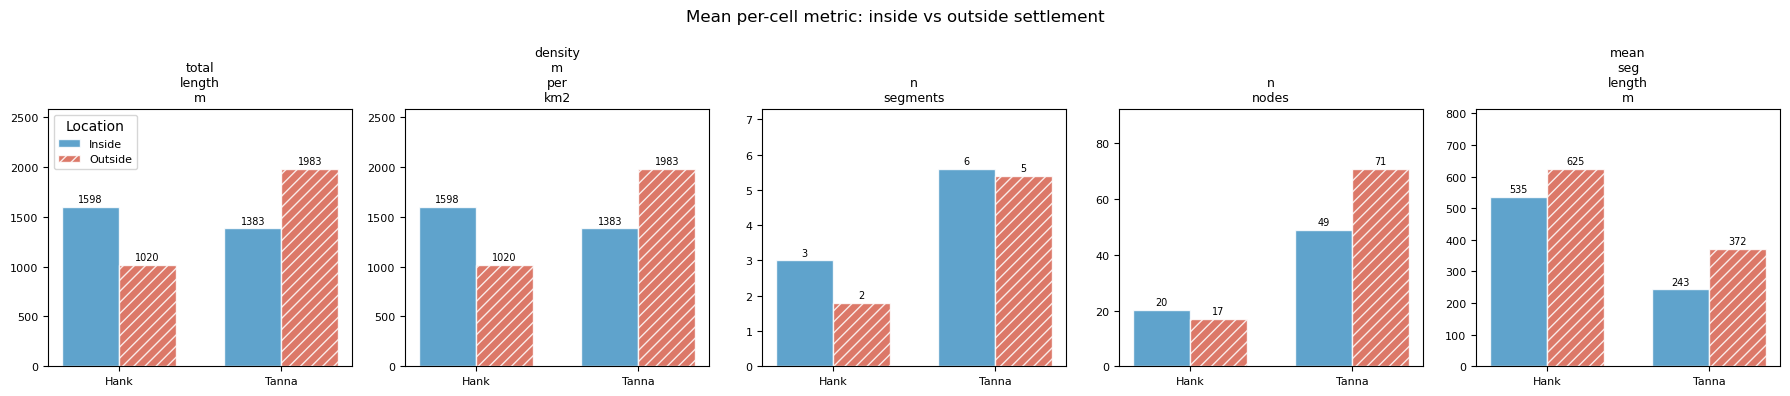

In [11]:
# ── Bar charts: inside vs outside, one subplot per metric ────────────────────
locations = ["Inside", "Outside"]
x_pos     = np.arange(len(LABELS))
bar_w     = 0.35

fig, axes = plt.subplots(1, len(AGG_COLS), figsize=(18, 4))
fig.suptitle("Mean per-cell metric: inside vs outside settlement", fontsize=12)

for ax, col in zip(axes, AGG_COLS):
    for offset, loc in zip([-bar_w / 2, bar_w / 2], locations):
        vals = [
            agg_location.loc[(loc, lbl), col]
            if (loc, lbl) in agg_location.index else 0
            for lbl in LABELS
        ]
        color  = "#4393c3" if loc == "Inside" else "#d6604d"
        hatch  = None      if loc == "Inside" else "///"
        bars   = ax.bar(x_pos + offset, vals, bar_w,
                        color=color, hatch=hatch, edgecolor="white",
                        label=loc, alpha=0.85)
        ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_title(col.replace("_", "\n"), fontsize=9)
    ax.tick_params(labelsize=8)
    ymax = max(v for v in [
        agg_location.loc[(loc, lbl), col]
        for loc in locations for lbl in LABELS
        if (loc, lbl) in agg_location.index
    ] + [1])
    ax.set_ylim(0, ymax * 1.3)

axes[0].legend(fontsize=8, title="Location")
plt.tight_layout()
plt.show()

In [12]:
# ── Within-participant inside vs outside: paired t-test ───────────────────────
print("=== Within-participant inside vs outside settlement (paired t-test) ===")
intra_rows = []
for label in LABELS:
    sub = cell_metrics[cell_metrics["participant"] == label]
    for col in AGG_COLS:
        inside_vals  = sub[sub["inside_settlement"]][col].dropna().values
        outside_vals = sub[~sub["inside_settlement"]][col].dropna().values
        n_in, n_out  = len(inside_vals), len(outside_vals)
        if n_in < 2 or n_out < 2:
            continue
        # Independent (not paired) because inside/outside sets are different cells
        _, p = stats.ttest_ind(inside_vals, outside_vals, equal_var=False)
        intra_rows.append(dict(
            participant   = label,
            metric        = col,
            mean_inside   = inside_vals.mean(),
            mean_outside  = outside_vals.mean(),
            n_inside      = n_in,
            n_outside     = n_out,
            ttest_p       = p,
        ))
display(pd.DataFrame(intra_rows).round(4))

=== Within-participant inside vs outside settlement (paired t-test) ===


,participant,metric,mean_inside,mean_outside,n_inside,n_outside,ttest_p
0,Hank,total_length_m,1597.7,1020.5,5,17,0.3
1,Hank,density_m_per_km2,1597.7,1020.5,5,17,0.3
2,Hank,n_segments,3.0,1.8,5,17,0.3
3,Hank,n_nodes,20.2,16.9,5,17,0.6
4,Hank,mean_seg_length_m,534.9,624.9,5,12,0.5
5,Tanna,total_length_m,1382.9,1982.9,5,17,0.2
6,Tanna,density_m_per_km2,1382.9,1982.9,5,17,0.2
7,Tanna,n_segments,5.6,5.4,5,17,0.8
8,Tanna,n_nodes,49.0,70.9,5,17,0.2
9,Tanna,mean_seg_length_m,243.0,371.7,5,17,0.1


## 5  Distribution and mean comparison plots

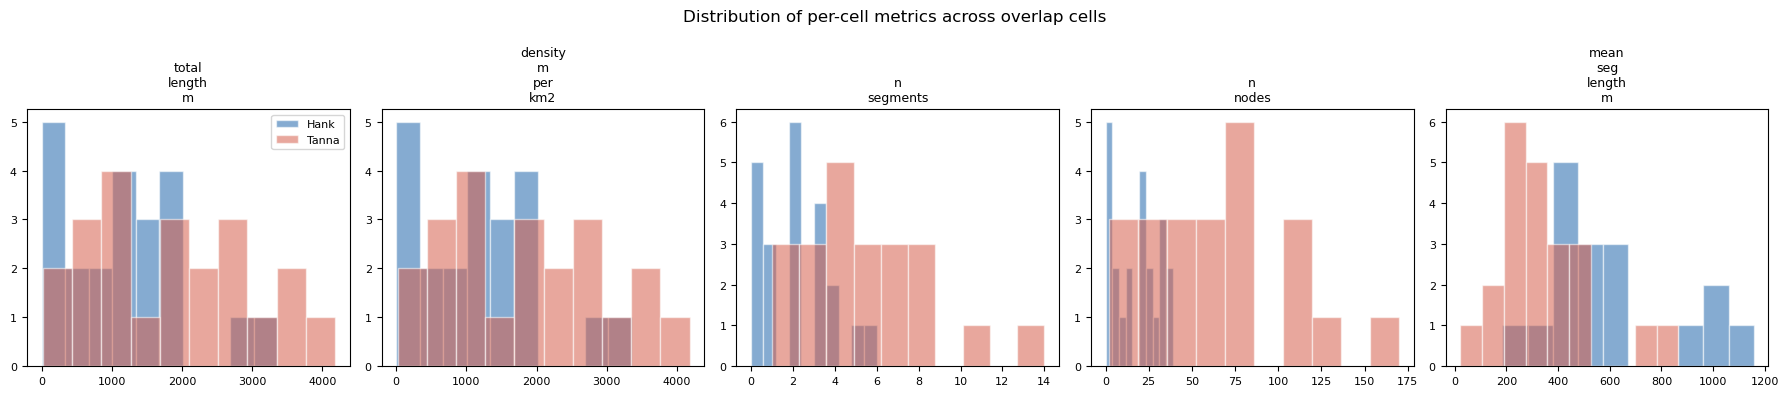

In [13]:
fig, axes = plt.subplots(1, len(AGG_COLS), figsize=(18, 4))
fig.suptitle("Distribution of per-cell metrics across overlap cells", fontsize=12)

for ax, col in zip(axes, AGG_COLS):
    for label in LABELS:
        vals = cell_metrics[cell_metrics["participant"] == label][col].dropna()
        ax.hist(vals, bins=10, alpha=0.55, color=COLORS[label],
                label=label, edgecolor="white")
    ax.set_title(col.replace("_", "\n"), fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

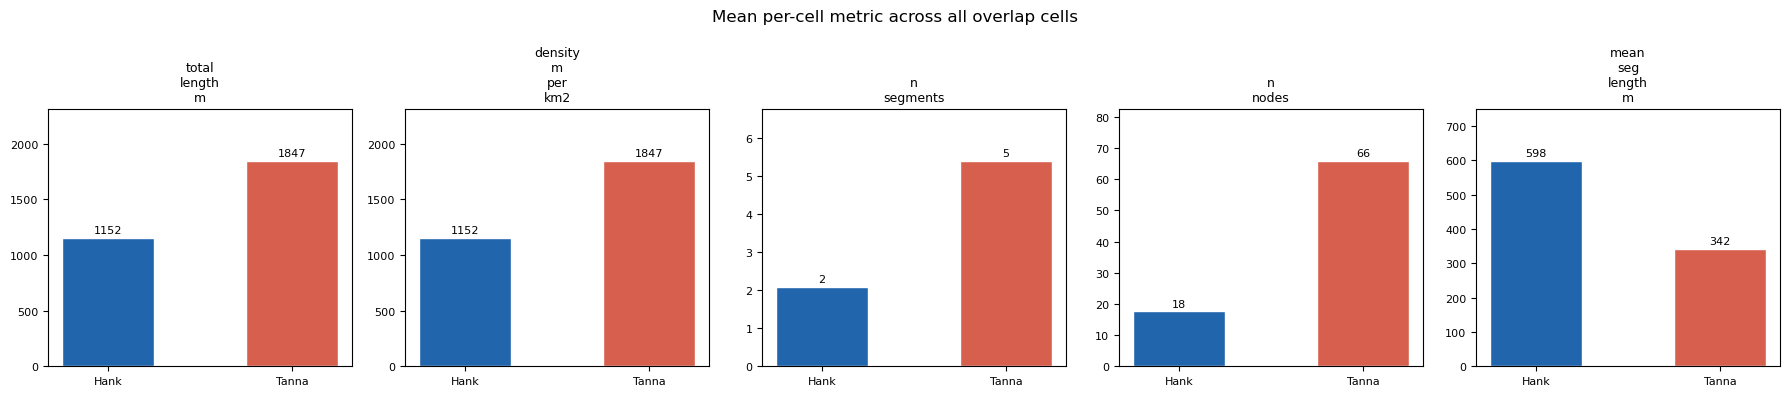

In [14]:
mean_vals = cell_metrics.groupby("participant")[AGG_COLS].mean().loc[LABELS]

fig, axes = plt.subplots(1, len(AGG_COLS), figsize=(18, 4))
fig.suptitle("Mean per-cell metric across all overlap cells", fontsize=12)

for ax, col in zip(axes, AGG_COLS):
    bars = ax.bar(
        mean_vals.index, mean_vals[col],
        color=[COLORS[p] for p in mean_vals.index],
        edgecolor="white", width=0.5,
    )
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=2)
    ax.set_title(col.replace("_", "\n"), fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, mean_vals[col].max() * 1.25)

plt.tight_layout()
plt.show()

## 6  Pairwise scatter plots

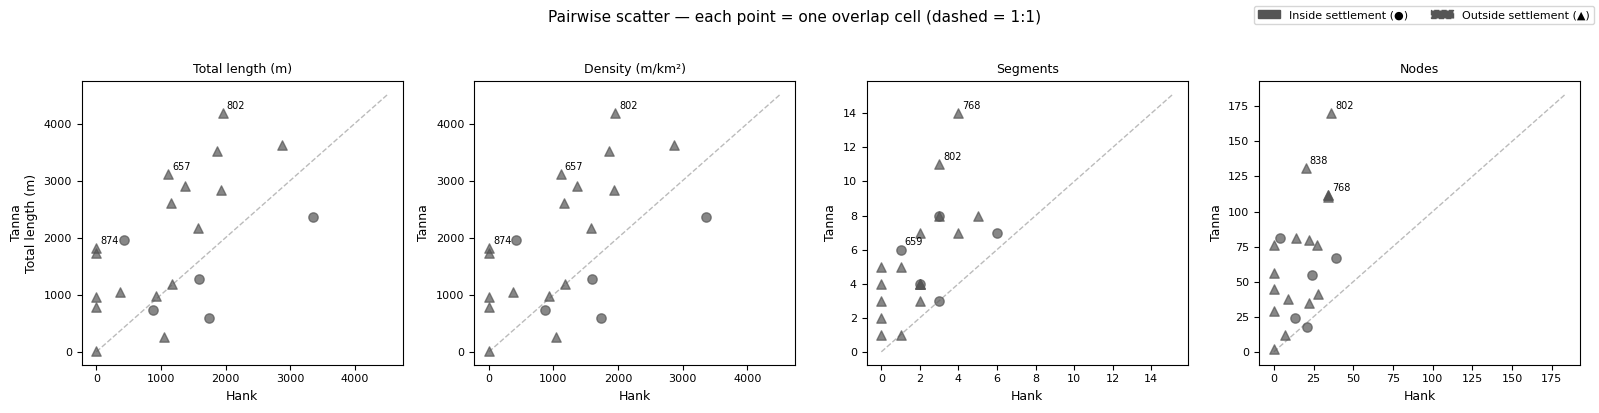

In [16]:
KEY_METRICS = [
    ("total_length_m",    "Total length (m)"),
    ("density_m_per_km2", "Density (m/km\u00b2)"),
    ("n_segments",        "Segments"),
    ("n_nodes",           "Nodes"),
]

# Inside/outside marker style
inside_oids  = set(overlap_grid[overlap_grid["inside_settlement"]]["OID"])
marker_style = ["o" if oid in inside_oids else "^"
                for oid in overlap_oids]

fig, axes = plt.subplots(
    len(pairs), len(KEY_METRICS),
    figsize=(len(KEY_METRICS) * 4, len(pairs) * 4),
    squeeze=False,
)

for row_i, (lA, lB) in enumerate(pairs):
    for col_i, (col, label) in enumerate(KEY_METRICS):
        ax = axes[row_i, col_i]
        x  = vals_by_p[lA].loc[overlap_oids, col].values
        y  = vals_by_p[lB].loc[overlap_oids, col].values
        for xi, yi, mk in zip(x, y, marker_style):
            ax.scatter(xi, yi, marker=mk, color="#555555", alpha=0.7, s=45, zorder=3)
        lim = max(np.nanmax(x), np.nanmax(y)) * 1.08
        ax.plot([0, lim], [0, lim], "--", color="#bbbbbb", linewidth=1, zorder=1)
        diffs = np.abs(x - y)
        for i in np.argsort(diffs)[-3:]:
            ax.annotate(str(overlap_oids[i]), (x[i], y[i]),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(lA, fontsize=9)
        ax.set_title(label if row_i == 0 else "", fontsize=9)
        ax.set_ylabel(f"{lB}\n{label}" if col_i == 0 else lB, fontsize=9)
        ax.tick_params(labelsize=8)

# Legend for inside/outside markers
legend_handles = [
    mpatches.Patch(color="#555555", label="Inside settlement (\u25cf)"),
    mpatches.Patch(color="#555555", label="Outside settlement (\u25b2)",
                   linestyle="--"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=8, ncol=2)
fig.suptitle("Pairwise scatter — each point = one overlap cell (dashed = 1:1)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7  Per-cell detail table

In [17]:
wide = cell_metrics.pivot(index="OID", columns="participant", values=AGG_COLS)
wide.columns = [f"{metric}_{p.lower()}" for metric, p in wide.columns]
wide = wide.reset_index()

# Add inside/outside tag
wide = wide.merge(
    overlap_grid[["OID", "inside_settlement"]].assign(
        location=overlap_grid["inside_settlement"].map(location_label)
    ),
    on="OID", how="left",
)

for col in AGG_COLS:
    p_cols = [f"{col}_{p.lower()}" for p in LABELS]
    wide[f"{col}_range"] = wide[p_cols].max(axis=1) - wide[p_cols].min(axis=1)

wide = wide.sort_values("total_length_m_range", ascending=False)
print("=== Per-cell metrics (sorted by total_length range) ===")
display(wide.drop(columns="inside_settlement").round(1))

=== Per-cell metrics (sorted by total_length range) ===


,OID,total_length_m_hank,total_length_m_tanna,density_m_per_km2_hank,density_m_per_km2_tanna,n_segments_hank,n_segments_tanna,n_nodes_hank,n_nodes_tanna,mean_seg_length_m_hank,mean_seg_length_m_tanna,location,total_length_m_range,density_m_per_km2_range,n_segments_range,n_nodes_range,mean_seg_length_m_range
14,802,1952.7,4179.1,1952.7,4179.1,3.0,11.0,36.0,170.0,650.9,379.9,Outside,2226.4,2226.4,8.0,134.0,271.0
2,657,1109.5,3111.1,1109.5,3111.1,2.0,7.0,34.0,112.0,554.7,444.4,Outside,2001.6,2001.6,5.0,78.0,110.3
20,874,0.0,1815.5,0.0,1815.5,0.0,5.0,0.0,76.0,NaN,363.1,Outside,1815.5,1815.5,5.0,76.0,0.0
16,804,0.0,1730.2,0.0,1730.2,0.0,2.0,0.0,56.0,NaN,865.1,Outside,1730.2,1730.2,2.0,56.0,0.0
13,768,1862.8,3517.5,1862.8,3517.5,4.0,14.0,34.0,112.0,465.7,251.3,Outside,1654.7,1654.7,10.0,78.0,214.5
17,838,1371.6,2902.4,1371.6,2902.4,3.0,8.0,20.0,131.0,457.2,362.8,Outside,1530.8,1530.8,5.0,111.0,94.4
4,659,422.6,1951.8,422.6,1951.8,1.0,6.0,4.0,81.0,422.6,325.3,Inside,1529.2,1529.2,5.0,77.0,97.3
15,803,1156.9,2614.2,1156.9,2614.2,1.0,5.0,14.0,81.0,1156.9,522.8,Outside,1457.3,1457.3,4.0,67.0,634.1
7,695,1737.1,594.4,1737.1,594.4,2.0,4.0,21.0,18.0,868.5,148.6,Inside,1142.7,1142.7,2.0,3.0,719.9
10,731,3356.3,2359.9,3356.3,2359.9,6.0,7.0,39.0,67.0,559.4,337.1,Inside,996.4,996.4,1.0,28.0,222.3


## 8  Individual cell maps — largest length discrepancy

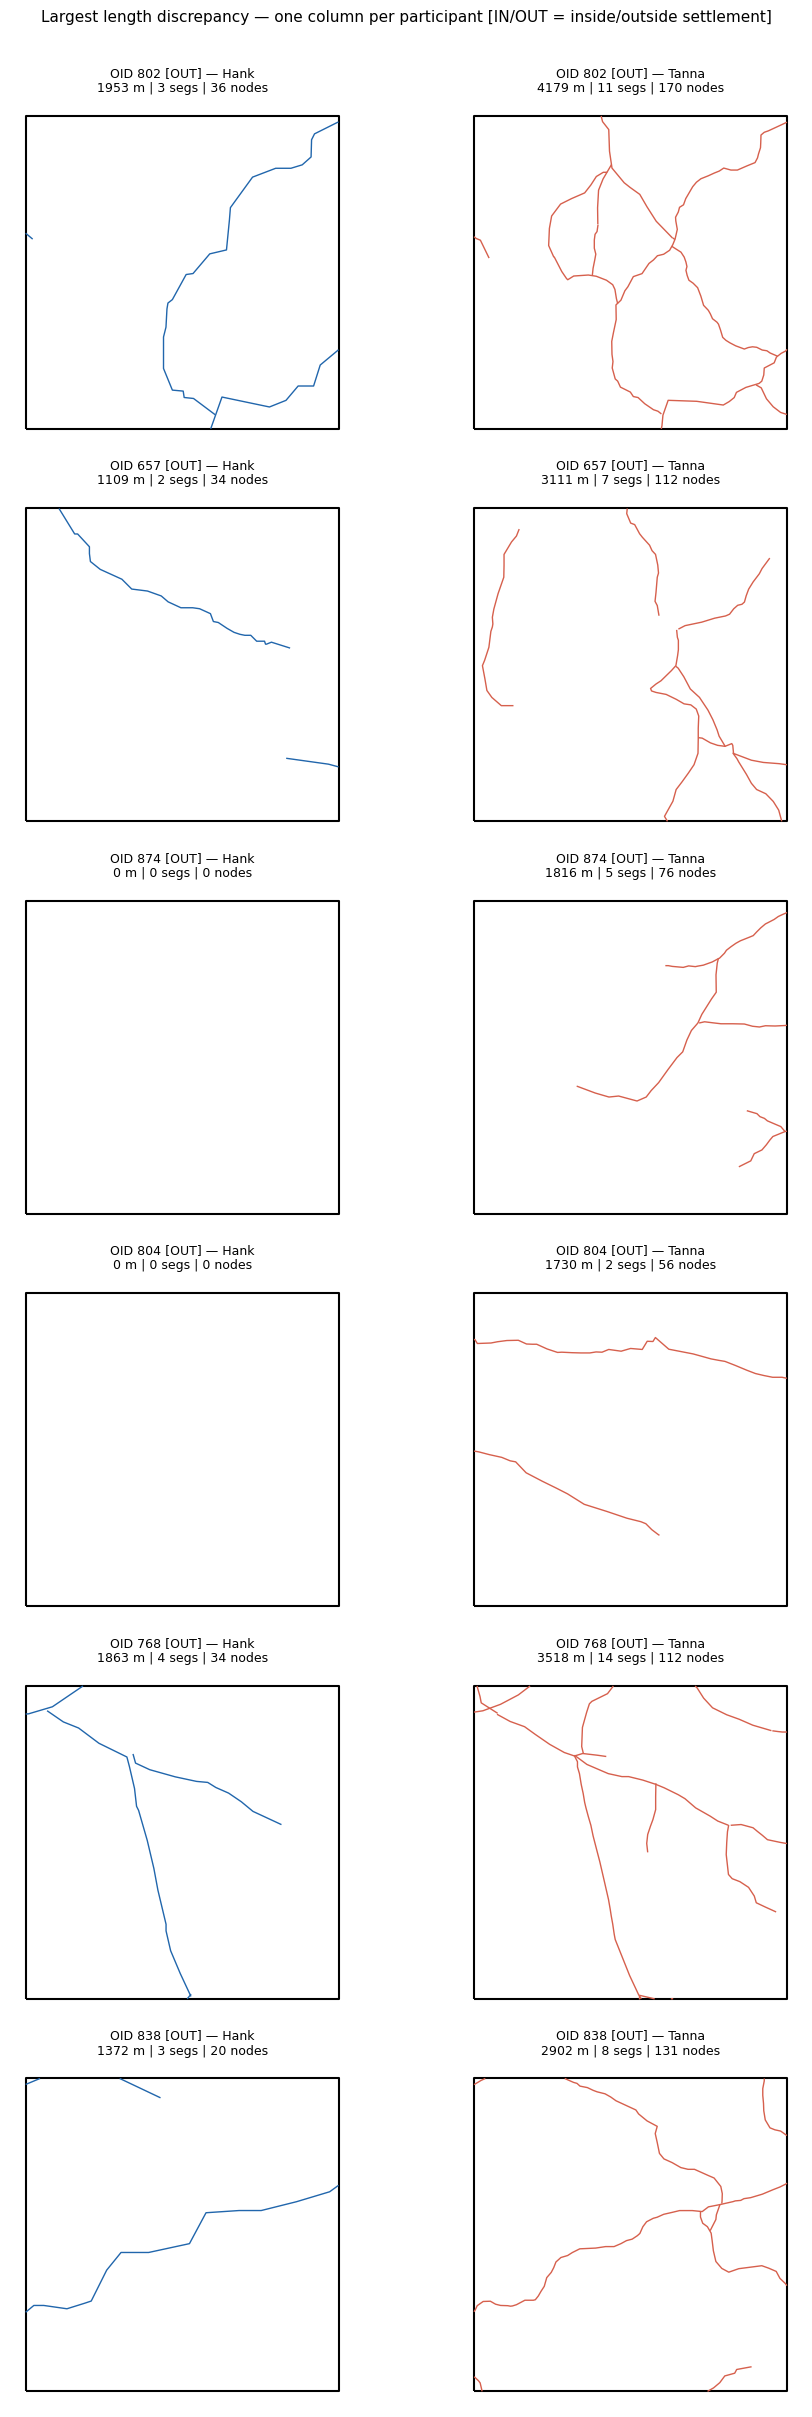

In [18]:
def _plot_cell(ax, label, oid, cell_geom, show_iou=None):
    """Plot one participant's digitization clipped to cell_geom."""
    gpd.GeoSeries([cell_geom]).boundary.plot(
        ax=ax, color="black", linewidth=1.5, zorder=1)
    clipped = lines_gdfs[label][lines_gdfs[label].intersects(cell_geom)].copy()
    if not clipped.empty:
        clipped["geometry"] = clipped.geometry.intersection(cell_geom)
        clipped = clipped[~clipped.geometry.is_empty]
    if not clipped.empty:
        clipped.plot(ax=ax, color=COLORS[label], linewidth=1.0, zorder=2)
    m = cell_metrics[
        (cell_metrics["OID"] == oid) & (cell_metrics["participant"] == label)
    ].iloc[0]
    iou_str = f"  IoU={show_iou:.2f}" if show_iou is not None else ""
    loc_str = "IN" if m.inside_settlement else "OUT"
    ax.set_title(
        f"OID {oid} [{loc_str}] — {label}{iou_str}\n"
        f"{m.total_length_m:.0f} m | {m.n_segments} segs | {m.n_nodes} nodes",
        fontsize=9,
    )
    ax.set_axis_off()


example_oids = wide.head(N_EXAMPLE_CELLS)["OID"].tolist()
n_cols = len(LABELS)

fig, axes = plt.subplots(N_EXAMPLE_CELLS, n_cols,
                         figsize=(n_cols * 5, N_EXAMPLE_CELLS * 4),
                         squeeze=False)
fig.suptitle("Largest length discrepancy — one column per participant [IN/OUT = inside/outside settlement]",
             fontsize=11, y=1.005)

for row_i, oid in enumerate(example_oids):
    cell_geom = overlap_grid.loc[overlap_grid["OID"] == oid, "geometry"].values[0]
    for col_i, label in enumerate(LABELS):
        _plot_cell(axes[row_i, col_i], label, oid, cell_geom)

plt.tight_layout()
plt.show()

## 9  Pairwise geometric agreement (buffered IoU)

In [19]:
def _clipped_buffer_union(lines_gdf, cell_geom, buf_m):
    sub = lines_gdf[lines_gdf.intersects(cell_geom)].copy()
    if sub.empty:
        return None
    sub["geometry"] = sub.geometry.intersection(cell_geom)
    sub = sub[~sub.geometry.is_empty]
    return unary_union(sub.geometry.buffer(buf_m)) if not sub.empty else None

def pairwise_iou(lA, lB, cell_geom, buf_m):
    pA = _clipped_buffer_union(lines_gdfs[lA], cell_geom, buf_m)
    pB = _clipped_buffer_union(lines_gdfs[lB], cell_geom, buf_m)
    if pA is None and pB is None:
        return np.nan
    if pA is None or pB is None:
        return 0.0
    union = pA.union(pB).area
    return pA.intersection(pB).area / union if union > 0 else np.nan


iou_rows = []
for _, cell_row in overlap_grid.iterrows():
    oid  = cell_row["OID"]
    geom = cell_row.geometry
    row  = {"OID": oid, "inside_settlement": cell_row["inside_settlement"]}
    for (lA, lB) in pairs:
        row[f"iou_{lA.lower()}_{lB.lower()}"] = pairwise_iou(lA, lB, geom, SNAP_BUFFER_M)
    iou_rows.append(row)

iou_df   = pd.DataFrame(iou_rows)
iou_cols = [c for c in iou_df.columns if c.startswith("iou_")]

print(f"=== IoU summary — all overlap cells (buffer={SNAP_BUFFER_M} m) ===")
display(iou_df[iou_cols].agg(["mean", "median", "min", "max"]).round(3))

=== IoU summary — all overlap cells (buffer=5 m) ===


,iou_hank_tanna
mean,0.1
median,0.1
min,0.0
max,0.5


In [20]:
# ── IoU inside vs outside settlement ─────────────────────────────────────────
iou_df["location"] = iou_df["inside_settlement"].map(location_label)
print("=== IoU by location ===")
display(
    iou_df.groupby("location")[iou_cols]
    .agg(["mean", "median", "min", "max"])
    .round(3)
)

=== IoU by location ===


iou_hank_tanna               
                   mean median min max
location                              
Inside              0.1    0.1 0.0 0.1
Outside             0.2    0.1 0.0 0.5

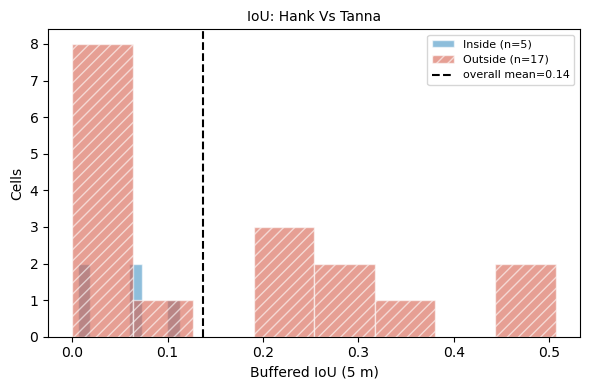

In [21]:
# ── IoU distribution plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(iou_cols),
                         figsize=(6 * len(iou_cols), 4), squeeze=False)

for ax, col in zip(axes[0], iou_cols):
    for loc, color, hatch in [("Inside", "#4393c3", None), ("Outside", "#d6604d", "///")]:
        vals = iou_df.loc[iou_df["location"] == loc, col].dropna()
        if not vals.empty:
            ax.hist(vals, bins=8, alpha=0.6, color=color, hatch=hatch,
                    edgecolor="white", label=f"{loc} (n={len(vals)})")
    overall_mean = iou_df[col].mean()
    ax.axvline(overall_mean, color="black", linestyle="--",
               label=f"overall mean={overall_mean:.2f}")
    pair_label = col.replace("iou_", "").replace("_", " vs ").title()
    ax.set_title(f"IoU: {pair_label}", fontsize=10)
    ax.set_xlabel(f"Buffered IoU ({SNAP_BUFFER_M} m)")
    ax.set_ylabel("Cells")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10  Individual cell maps — lowest pairwise IoU

Lowest-IoU cells (iou_hank_tanna): [694, 730, 840, 804, 874, 875]


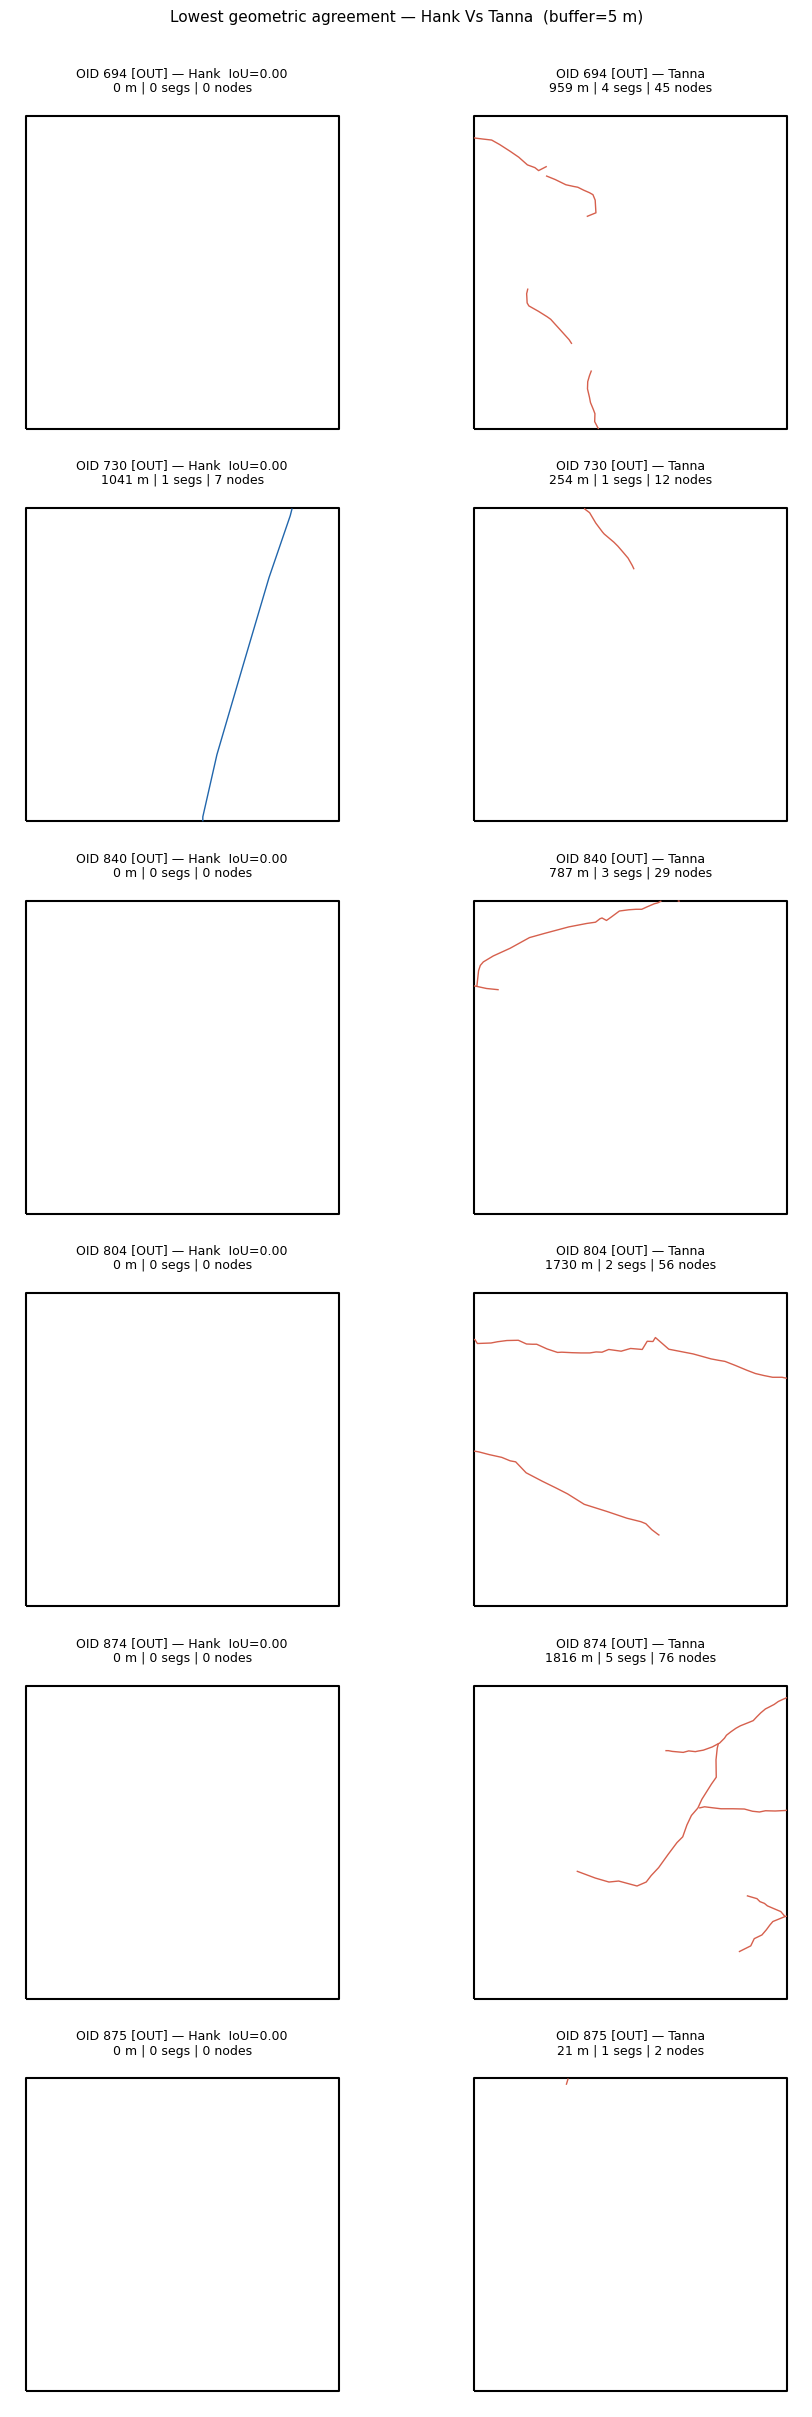

In [22]:
_sort_col = iou_cols[0]  # change to iou_cols[1] etc. for other pairs

low_iou_oids = iou_df.sort_values(_sort_col).head(N_EXAMPLE_CELLS)["OID"].tolist()
print(f"Lowest-IoU cells ({_sort_col}): {low_iou_oids}")

fig, axes = plt.subplots(N_EXAMPLE_CELLS, len(LABELS),
                         figsize=(len(LABELS) * 5, N_EXAMPLE_CELLS * 4),
                         squeeze=False)
fig.suptitle(
    f"Lowest geometric agreement — {_sort_col.replace('iou_','').replace('_',' vs ').title()}"
    f"  (buffer={SNAP_BUFFER_M} m)",
    fontsize=11, y=1.005
)

for row_i, oid in enumerate(low_iou_oids):
    cell_geom = overlap_grid.loc[overlap_grid["OID"] == oid, "geometry"].values[0]
    iou_val   = iou_df.loc[iou_df["OID"] == oid, _sort_col].values[0]
    for col_i, label in enumerate(LABELS):
        _plot_cell(axes[row_i, col_i], label, oid, cell_geom,
                   show_iou=iou_val if col_i == 0 else None)

plt.tight_layout()
plt.show()

## 11  Random overlap cell explorer

Re-run this cell to draw a new random overlap cell with all participants' digitizations
overlaid on a single axes. Set `RANDOM_OID` to a specific integer to pin a cell.

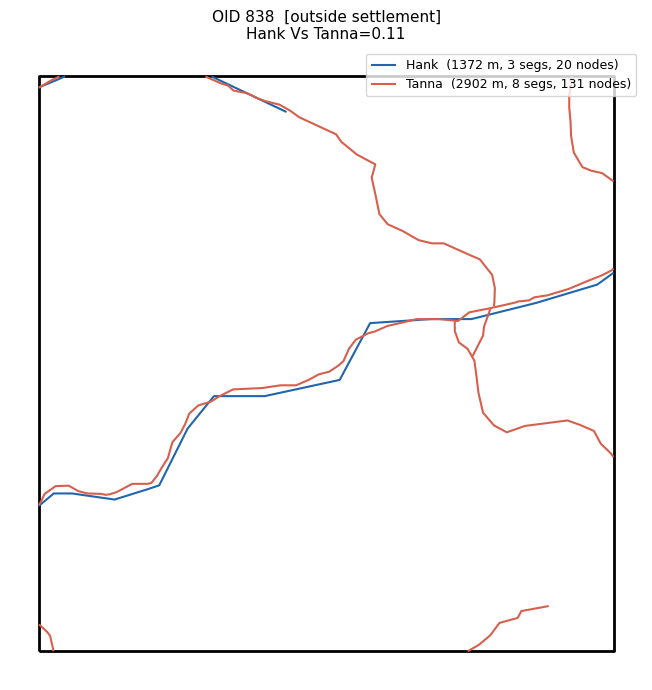

Showing OID 838 (outside settlement boundary)


In [23]:
RANDOM_OID = None   # set to an integer OID to pin a specific cell, or leave None for random

rng = np.random.default_rng()  # fresh RNG each run → different cell each time
oid = int(rng.choice(overlap_oids)) if RANDOM_OID is None else RANDOM_OID

cell_geom = overlap_grid.loc[overlap_grid["OID"] == oid, "geometry"].values[0]
inside    = overlap_grid.loc[overlap_grid["OID"] == oid, "inside_settlement"].values[0]
iou_row   = iou_df.loc[iou_df["OID"] == oid].iloc[0] if len(iou_cols) else None

fig, ax = plt.subplots(figsize=(7, 7))

# Cell boundary
gpd.GeoSeries([cell_geom]).boundary.plot(ax=ax, color="black", linewidth=2.0, zorder=1)

# Settlement boundary clipped to cell extent
settlement_clip = settlement.clip(cell_geom)
if not settlement_clip.empty:
    settlement_clip.boundary.plot(
        ax=ax, color="#888888", linewidth=1.2, linestyle="--", zorder=2,
        label="settlement boundary"
    )

# Each participant's digitization
for label in LABELS:
    clipped = lines_gdfs[label][lines_gdfs[label].intersects(cell_geom)].copy()
    if not clipped.empty:
        clipped["geometry"] = clipped.geometry.intersection(cell_geom)
        clipped = clipped[~clipped.geometry.is_empty]
    if not clipped.empty:
        m = cell_metrics[
            (cell_metrics["OID"] == oid) & (cell_metrics["participant"] == label)
        ].iloc[0]
        clipped.plot(
            ax=ax, color=COLORS[label], linewidth=1.5, zorder=3,
            label=f"{label}  ({m.total_length_m:.0f} m, "
                  f"{m.n_segments} segs, {m.n_nodes} nodes)",
        )

loc_str  = "inside" if inside else "outside"
iou_strs = [f"{c.replace('iou_','').replace('_',' vs ').title()}={iou_row[c]:.2f}"
            for c in iou_cols] if iou_row is not None else []

ax.set_title(
    f"OID {oid}  [{loc_str} settlement]\n" + ("  ".join(iou_strs) if iou_strs else ""),
    fontsize=11
)
ax.legend(fontsize=9, loc="upper right")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Showing OID {oid} ({loc_str} settlement boundary)")

## 12  Summary

In [24]:
print("=" * 65)
print("DIGITIZATION COMPARISON SUMMARY")
print(f"Settlement  : {SETTLEMENT.capitalize()}  |  Grid: {CELL_SIZE_M} m")
print(f"Overlap cells: {len(overlap_oids)}  "
      f"({n_inside} inside / {n_outside} outside settlement)")
print(f"Participants: {', '.join(LABELS)}")
print("=" * 65)

for label in LABELS:
    sub = cell_metrics[cell_metrics["participant"] == label]
    sin = sub[sub["inside_settlement"]]
    sout = sub[~sub["inside_settlement"]]
    print(f"\n{label}  (all / inside / outside):")
    for metric, fmt in [("total_length_m", ".0f"), ("density_m_per_km2", ".0f"),
                        ("n_segments", ".1f"), ("n_nodes", ".1f")]:
        a = format(sub[metric].mean(), fmt)
        i = format(sin[metric].mean(), fmt) if not sin.empty else "—"
        o = format(sout[metric].mean(), fmt) if not sout.empty else "—"
        print(f"  {metric:<24} {a:>8} / {i:>8} / {o:>8}")

print(f"\nPairwise IoU (buffer={SNAP_BUFFER_M} m):")
for col in iou_cols:
    pair_label = col.replace("iou_", "").replace("_", " vs ").title()
    v = iou_df[col].dropna()
    v_in  = iou_df.loc[iou_df["inside_settlement"],  col].dropna()
    v_out = iou_df.loc[~iou_df["inside_settlement"], col].dropna()
    worst = iou_df.loc[iou_df[col].idxmin(), "OID"]
    print(f"  {pair_label:<22} overall={v.mean():.3f}  "
          f"inside={v_in.mean():.3f}  outside={v_out.mean():.3f}  "
          f"min={v.min():.3f} (OID {worst})")

DIGITIZATION COMPARISON SUMMARY
Settlement  : Palabek  |  Grid: 1000 m
Overlap cells: 22  (5 inside / 17 outside settlement)
Participants: Hank, Tanna

Hank  (all / inside / outside):
  total_length_m               1152 /     1598 /     1020
  density_m_per_km2            1152 /     1598 /     1020
  n_segments                    2.1 /      3.0 /      1.8
  n_nodes                      17.6 /     20.2 /     16.9

Tanna  (all / inside / outside):
  total_length_m               1847 /     1383 /     1983
  density_m_per_km2            1847 /     1383 /     1983
  n_segments                    5.4 /      5.6 /      5.4
  n_nodes                      66.0 /     49.0 /     70.9

Pairwise IoU (buffer=5 m):
  Hank Vs Tanna          overall=0.137  inside=0.055  outside=0.161  min=0.000 (OID 694)
